In [1]:
%reload_ext autoreload
%autoreload 2

In [21]:

import jax
import jax.numpy as jnp
from flax import nnx

from probjax.nn import AdditiveCouplingFlow, AffineAutoregressiveFlow, SplineAutoregressiveFlow
from probjax.nn.bijective import affine_bijector, additive_bijector
from probjax.nn.nets.autoregressive import AutoregressiveMLP
from probjax.core import inverse


In [22]:
p = SplineAutoregressiveFlow(4, 2, nnx.Rngs(1))

graph_def, params, state = nnx.split(p, nnx.Param,...)


In [23]:
x1 = jax.random.normal(jax.random.PRNGKey(0), (1000, 4)) -2
x2 = jax.random.normal(jax.random.PRNGKey(1), (1000, 4)) +2

xs = jnp.concatenate([x1, x2], axis=0)

In [24]:
def loss(params):
    p = nnx.merge(graph_def, params, state)
    return -jnp.mean(p.logpdf(xs))

In [25]:
loss(params)

ValueError: vmap got inconsistent sizes for array axes to be mapped:
  * one axis had size 4: axis 0 of argument params of type float32[4,30];
  * one axis had size 1: axis 0 of argument x of type float32[1]

In [7]:
import optax

optimizer = optax.adam(5e-4)

@jax.jit
def update(params, opt_state):
    loss_val, grads = jax.value_and_grad(loss)(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss_val, new_params, opt_state

In [8]:
opt_state = optimizer.init(params)

In [17]:
for i in range(10000):
    loss_val, params, opt_state = update(params, opt_state)
    print(loss_val)

6.0789633
6.078885
6.0788107
6.0787444
6.078682
6.0786204
6.078558
6.0784965
6.0784354
6.078377
6.0783224
6.078274
6.0782375
6.0782285
6.0782843
6.0784965
6.0791125
6.0807815
6.0854907
6.098386
6.134798
6.214472
6.3467517
6.284691
6.118801
6.178463
6.1533165
6.1040025
6.1550307
6.1048756
6.1346397
6.107601
6.1322937
6.116684
6.1130137
6.1196566
6.104369
6.1160836
6.1063967
6.1132927
6.107142
6.1075606
6.1097193
6.1008353
6.1028
6.1019745
6.095958
6.104431
6.0937114
6.1012497
6.096711
6.0981607
6.099259
6.1128454
6.0985546
6.0944366
6.0972896
6.0903573
6.090796
6.0923605
6.0922804
6.090428
6.088391
6.0891185
6.088485
6.0878744
6.0877233
6.0872874
6.0868354
6.086471
6.0866733
6.0860415
6.08567
6.085707
6.085695
6.085167
6.0851555
6.084742
6.0846066
6.0847735
6.084403
6.084147
6.084013
6.083973
6.0837827
6.083674
6.083627
6.0832963
6.0833097
6.083232
6.083056
6.0829835
6.0828285
6.0827384
6.0826583
6.0825577
6.0824213
6.0823584
6.0822825
6.082167
6.0820847
6.082015
6.0819087
6.081839
6.08

In [18]:
nnx.update(p, params)

In [19]:
samples = p.sample(jax.random.PRNGKey(0), (1000, ))

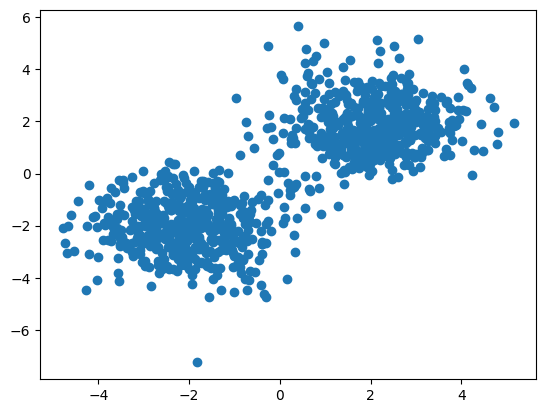

In [20]:
import matplotlib.pyplot as plt

plt.scatter(samples[:, 0], samples[:, 1])